# LeNet-1 with PyTorch

Good readings:

* [LeCun backpropagation applied to handwritten zip code recognition](https://ieeexplore.ieee.org/document/6795724 )
* [GradientBased Learning Applied to Document Recognition](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf)

## Preparations

As usual, let's start with the following preparations.

In [122]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

## USPS Dataset

The first paper on LeNet-1 used the USPS dataset. We will load and format the dataset. As the results, we will have `n` samples of `(16 x 16)` arrays for both the training and testing datasets.

In [123]:
import h5py
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

with h5py.File("./datasets/usps/usps.h5", "r") as hf:
    x_train = hf["train"]["data"][:].reshape(-1, 16, 16).astype(np.float32)
    y_train = hf["train"]["target"][:].astype(np.int64)

    x_test  = hf["test"]["data"][:].reshape(-1, 16, 16).astype(np.float32)
    y_test  = hf["test"]["target"][:].astype(np.int64)

# If your data is already [0,1], keep it.
# If you *really* want 0..255, uncomment the next two lines:
# x_train *= 255.0
# x_test  *= 255.0



# Convert to torch + add channel dim + NCHW
x_train = torch.from_numpy(x_train).unsqueeze(1)  # (N,1,16,16)
x_test  = torch.from_numpy(x_test).unsqueeze(1)

y_train = torch.from_numpy(y_train).long()        # (N,)
y_test  = torch.from_numpy(y_test).long()

print("Training data:")
print("Dimension numbers :", x_test.shape[1] * x_train.shape[2] * x_train.shape[3])
print("Number of data    :", x_train.shape[0])

print("\nTesting data:")
print("Dimension numbers :", x_test.shape[1] * x_test.shape[2] * x_test.shape[3])
print("Number of data    :", x_test.shape[0])

Training data:
Dimension numbers : 256
Number of data    : 7291

Testing data:
Dimension numbers : 256
Number of data    : 2007


Let's plot some of the data for visualization purposes.

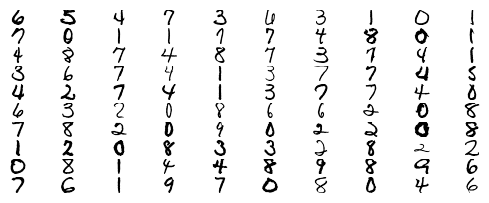

In [124]:
for i in range(100):
    X = x_train[i,0,:,:]
    plt.subplot(20, 10, i + 1)
    plt.imshow(X, cmap='Greys')
    plt.axis('off')

## Building the Model Architecture


All kerenels are `5 x 5`. To maintain the image dimension, we apply two layers of zero-padding. The stride length for the convolution is `1`.

Down sizing the features are done by using max pooling with a window of `2 x 2` and a stride length of `2`.

![](./images/lenet-1.png)

Create the Keras sequential model based on the model architecture diagram.

The sequential order of the CNN is as follows: 

`input --> C1 --> reLU --> M1 --> C2 --> ReLU --> M2 --> FCN`

where C and M are convolutional and max-pooling layers, respectively. FCN is a fully-connected network layer.

In [ ]:
model = nn.Sequential(
    nn.ZeroPad2d(2),
    nn.Conv2d(in_channels=1, out_channels=12, kernel_size=5, stride=1, padding=0),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.ZeroPad2d(2),
    nn.Conv2d(in_channels=12, out_channels=12, kernel_size=5, stride=1, padding=0),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(192, 30),
    nn.ReLU(inplace=True),
    nn.Linear(30, 10),  # logits (use CrossEntropyLoss)
)

## Compile and Train

### Prepare Training and Test Datasets

In [126]:
batch_size = 64

train_loader = DataLoader(
    TensorDataset(x_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(x_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

### Training

- zero past gradients (otherwise PyTorch accumulates)
- forward pass (compute logits/output)
- compute loss (compare logits/output vs labels)
- backward pass (compute gradients via backpropagation)
- optimizer step (apply gradient descent to update parameters)
- repeat until loss becomes sufficiently small

In [127]:
device = torch.device("cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 30
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device).long()

        optimizer.zero_grad() # zero gradients
        logits = model(xb) # forward pass
        loss = criterion(logits, yb) # compute loss
        loss.backward() # compute gradients
        optimizer.step() # update parameters

        total_loss += loss.item()
        total_acc  += (logits.argmax(1) == yb).float().mean().item()
        n += 1

    print(f"Epoch {epoch:02d} | loss {total_loss/n:.4f} | acc {total_acc/n*100:.2f}%")

Epoch 01 | loss 2.2757 | acc 17.61%
Epoch 02 | loss 2.0455 | acc 34.68%
Epoch 03 | loss 1.5068 | acc 55.64%
Epoch 04 | loss 1.0244 | acc 71.99%
Epoch 05 | loss 0.7295 | acc 79.54%
Epoch 06 | loss 0.5584 | acc 84.69%
Epoch 07 | loss 0.4476 | acc 87.61%
Epoch 08 | loss 0.3786 | acc 89.28%
Epoch 09 | loss 0.3357 | acc 90.29%
Epoch 10 | loss 0.3070 | acc 91.11%
Epoch 11 | loss 0.2857 | acc 91.88%
Epoch 12 | loss 0.2706 | acc 92.33%
Epoch 13 | loss 0.2548 | acc 92.66%
Epoch 14 | loss 0.2433 | acc 93.10%
Epoch 15 | loss 0.2355 | acc 93.31%
Epoch 16 | loss 0.2279 | acc 93.57%
Epoch 17 | loss 0.2180 | acc 94.02%
Epoch 18 | loss 0.2121 | acc 94.19%
Epoch 19 | loss 0.2066 | acc 94.22%
Epoch 20 | loss 0.1987 | acc 94.51%
Epoch 21 | loss 0.1945 | acc 94.79%
Epoch 22 | loss 0.1897 | acc 94.85%
Epoch 23 | loss 0.1853 | acc 95.05%
Epoch 24 | loss 0.1809 | acc 95.10%
Epoch 25 | loss 0.1771 | acc 94.97%
Epoch 26 | loss 0.1720 | acc 95.47%
Epoch 27 | loss 0.1689 | acc 95.21%
Epoch 28 | loss 0.1653 | acc

## Test Accuracy

Lest evaluate the training results with the test dataset.

In [128]:
model.eval()
total_loss = 0.0
total_acc = 0.0
n = 0

for xb, yb in test_loader:
    xb = xb.to(device)
    yb = yb.to(device).long()

    logits = model(xb) # forward pass
    loss = criterion(logits, yb) # compute loss

    total_loss += loss.item()
    total_acc  += (logits.argmax(1) == yb).float().mean().item()
    n += 1

print("Average Loss:", total_loss/n)
print("Average Accuracy:", total_acc/n)

Average Loss: 0.33418991416692734
Average Accuracy: 0.9258873984217644


## Explore the Trained Parameters

In [131]:
for k in range(len(model)):
    print(model[k])
    print("Number of parameters:", sum(p.numel() for p in model[k].parameters()))
    print("-------------------------------------------------")

ZeroPad2d((2, 2, 2, 2))
Number of parameters: 0
-------------------------------------------------
Conv2d(1, 12, kernel_size=(5, 5), stride=(1, 1))
Number of parameters: 312
-------------------------------------------------
ReLU(inplace=True)
Number of parameters: 0
-------------------------------------------------
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
Number of parameters: 0
-------------------------------------------------
ZeroPad2d((2, 2, 2, 2))
Number of parameters: 0
-------------------------------------------------
Conv2d(12, 12, kernel_size=(5, 5), stride=(1, 1))
Number of parameters: 3612
-------------------------------------------------
ReLU(inplace=True)
Number of parameters: 0
-------------------------------------------------
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
Number of parameters: 0
-------------------------------------------------
Flatten(start_dim=1, end_dim=-1)
Number of parameters: 0
-----------